In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.svm import SVC

In [2]:
data=pd.read_csv("C:\\Users\\aryan\\Downloads\\loan_approval.csv")

In [3]:
data.head()

,Age,Gender,Marital_Status,Education,City_Type,Dependents,Applicant_Type,Employment_Type,Employment_Business_Age,Monthly_Income,...,House_Ownership,Property_Value,Vehicle_Ownership,Collateral_Value,Loan_Type,Loan_Amount,Loan_Tenure,Loan_Purpose,Previous_Loan,Loan_Approved
0,40,Male,Married,High School,Semi-Urban,1.0,Self-Employed,Self-Employed,13.0,40000.0,...,Owned,570000.0,Yes,0.0,Home,590000,240,Home Renovation,Yes,Yes
1,27,Female,Married,Post Graduate,Rural,3.0,Business,Business,3.0,88000.0,...,Family,640000.0,Yes,450000.0,Business,3185000,84,Working Capital,No,No
2,44,Female,Married,High School,Semi-Urban,3.0,Business,Business,17.0,145500.0,...,Owned,16640000.0,Yes,NaN,Personal,740000,12,Medical,Yes,Yes
3,46,Female,Married,High School,Rural,2.0,Business,Business,9.0,117500.0,...,Owned,6210000.0,No,0.0,Home,7655000,240,Home Purchase,Yes,No
4,21,Female,Single,Graduate,Urban,0.0,Business,Business,0.0,20000.0,...,Family,1340000.0,No,0.0,Business,925000,60,Business Expansion,Yes,No


<h1>Total Null Values</h1>

In [4]:
data.isnull().sum()

Age                           0
Gender                        0
Marital_Status             1031
Education                  1519
City_Type                     0
Dependents                  941
Applicant_Type                0
Employment_Type               0
Employment_Business_Age    1506
Monthly_Income             1981
Monthly_Expenses           1975
Other_Income               2472
Existing_Loan                 0
Existing_Loan_Amount          0
Monthly_EMI                   0
Bank_Balance               2469
Savings_Amount             2520
Credit_Score               1534
Credit_History_Length       967
Late_Payments              1488
House_Ownership               0
Property_Value             1518
Vehicle_Ownership             0
Collateral_Value           1008
Loan_Type                     0
Loan_Amount                   0
Loan_Tenure                   0
Loan_Purpose                  0
Previous_Loan                 0
Loan_Approved                 0
dtype: int64

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Age                      100000 non-null  int64  
 1   Gender                   100000 non-null  str    
 2   Marital_Status           98969 non-null   str    
 3   Education                98481 non-null   str    
 4   City_Type                100000 non-null  str    
 5   Dependents               99059 non-null   float64
 6   Applicant_Type           100000 non-null  str    
 7   Employment_Type          100000 non-null  str    
 8   Employment_Business_Age  98494 non-null   float64
 9   Monthly_Income           98019 non-null   float64
 10  Monthly_Expenses         98025 non-null   float64
 11  Other_Income             97528 non-null   float64
 12  Existing_Loan            100000 non-null  str    
 13  Existing_Loan_Amount     100000 non-null  int64  
 14  Monthly_EMI     

<h1>Fill Null Values</h1>

In [6]:
select_numeric_data = data.select_dtypes(include="number").columns

In [7]:
select_object_data=data.select_dtypes(include="str").columns

In [8]:
print("Numeric Data columns is:-",select_numeric_data)
print("Object Data Columns is:-",select_object_data)

Numeric Data columns is:- Index(['Age', 'Dependents', 'Employment_Business_Age', 'Monthly_Income',
       'Monthly_Expenses', 'Other_Income', 'Existing_Loan_Amount',
       'Monthly_EMI', 'Bank_Balance', 'Savings_Amount', 'Credit_Score',
       'Credit_History_Length', 'Late_Payments', 'Property_Value',
       'Collateral_Value', 'Loan_Amount', 'Loan_Tenure'],
      dtype='str')
Object Data Columns is:- Index(['Gender', 'Marital_Status', 'Education', 'City_Type', 'Applicant_Type',
       'Employment_Type', 'Existing_Loan', 'House_Ownership',
       'Vehicle_Ownership', 'Loan_Type', 'Loan_Purpose', 'Previous_Loan',
       'Loan_Approved'],
      dtype='str')


In [9]:
for i in select_numeric_data:
    data[i]=data[i].fillna(data[i].mean())

In [10]:
data[select_object_data].mode()

,Gender,Marital_Status,Education,City_Type,Applicant_Type,Employment_Type,Existing_Loan,House_Ownership,Vehicle_Ownership,Loan_Type,Loan_Purpose,Previous_Loan,Loan_Approved
0,Male,Married,Graduate,Urban,Salaried,Private,No,Owned,No,Personal,Home Purchase,Yes,Yes


In [11]:
data[select_object_data]=data[select_object_data].fillna(data[select_object_data].mode().iloc[0])

In [12]:
data.isnull().sum()

Age                        0
Gender                     0
Marital_Status             0
Education                  0
City_Type                  0
Dependents                 0
Applicant_Type             0
Employment_Type            0
Employment_Business_Age    0
Monthly_Income             0
Monthly_Expenses           0
Other_Income               0
Existing_Loan              0
Existing_Loan_Amount       0
Monthly_EMI                0
Bank_Balance               0
Savings_Amount             0
Credit_Score               0
Credit_History_Length      0
Late_Payments              0
House_Ownership            0
Property_Value             0
Vehicle_Ownership          0
Collateral_Value           0
Loan_Type                  0
Loan_Amount                0
Loan_Tenure                0
Loan_Purpose               0
Previous_Loan              0
Loan_Approved              0
dtype: int64

In [13]:
data.duplicated().sum()

0

In [14]:
data.head()

,Age,Gender,Marital_Status,Education,City_Type,Dependents,Applicant_Type,Employment_Type,Employment_Business_Age,Monthly_Income,...,House_Ownership,Property_Value,Vehicle_Ownership,Collateral_Value,Loan_Type,Loan_Amount,Loan_Tenure,Loan_Purpose,Previous_Loan,Loan_Approved
0,40,Male,Married,High School,Semi-Urban,1.0,Self-Employed,Self-Employed,13.0,40000.0,...,Owned,570000.0,Yes,0.000000,Home,590000,240,Home Renovation,Yes,Yes
1,27,Female,Married,Post Graduate,Rural,3.0,Business,Business,3.0,88000.0,...,Family,640000.0,Yes,450000.000000,Business,3185000,84,Working Capital,No,No
2,44,Female,Married,High School,Semi-Urban,3.0,Business,Business,17.0,145500.0,...,Owned,16640000.0,Yes,892363.574834,Personal,740000,12,Medical,Yes,Yes
3,46,Female,Married,High School,Rural,2.0,Business,Business,9.0,117500.0,...,Owned,6210000.0,No,0.000000,Home,7655000,240,Home Purchase,Yes,No
4,21,Female,Single,Graduate,Urban,0.0,Business,Business,0.0,20000.0,...,Family,1340000.0,No,0.000000,Business,925000,60,Business Expansion,Yes,No


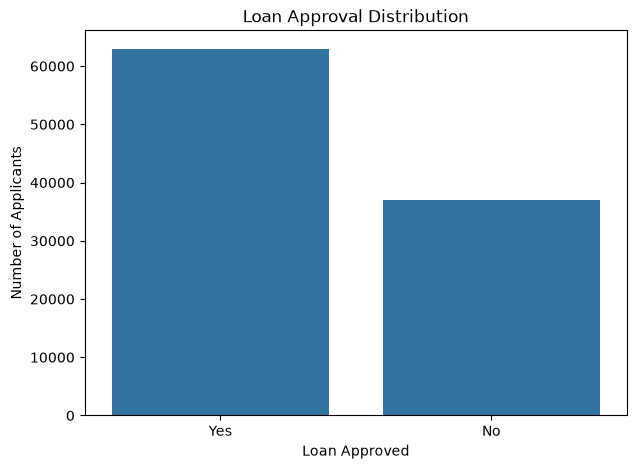

In [15]:
plt.figure(figsize=(7,5))
sns.countplot(data=data,x="Loan_Approved")
plt.title("Loan Approval Distribution")
plt.xlabel("Loan Approved")
plt.ylabel("Number of Applicants")
plt.show()

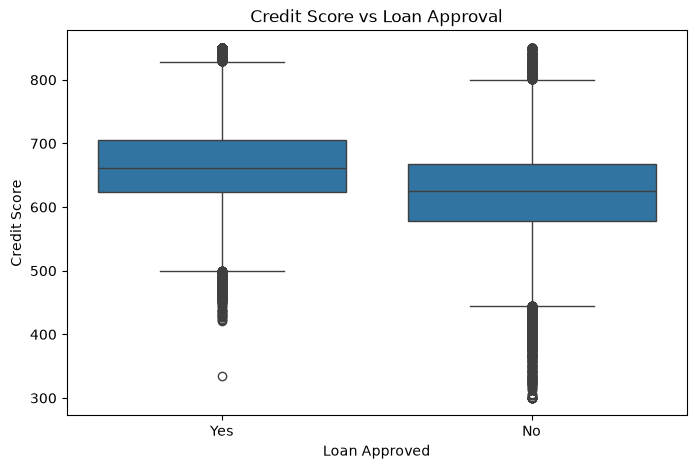

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(data=data,x="Loan_Approved",y="Credit_Score")
plt.title("Credit Score vs Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Credit Score")
plt.show()

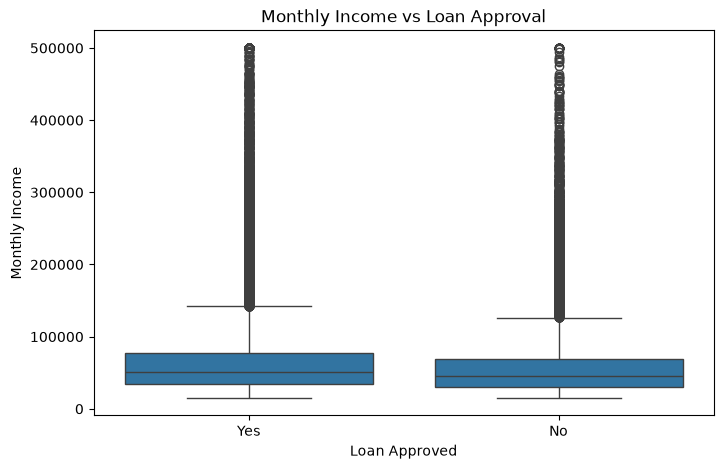

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(data=data,x="Loan_Approved",y="Monthly_Income")
plt.title("Monthly Income vs Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Monthly Income")
plt.show()

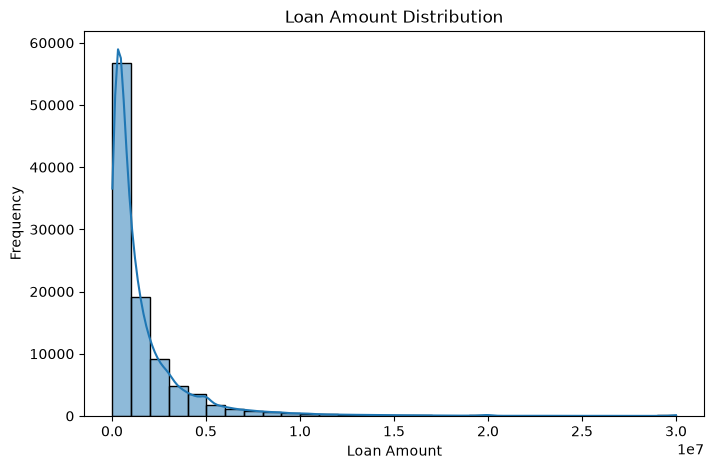

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(data=data,x="Loan_Amount",bins=30,kde=True)
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

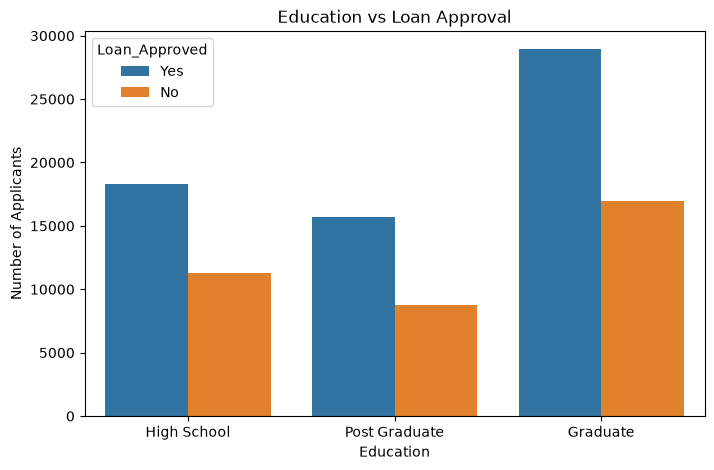

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(data=data,x="Education",hue="Loan_Approved")
plt.title("Education vs Loan Approval")
plt.xlabel("Education")
plt.ylabel("Number of Applicants")
plt.show()

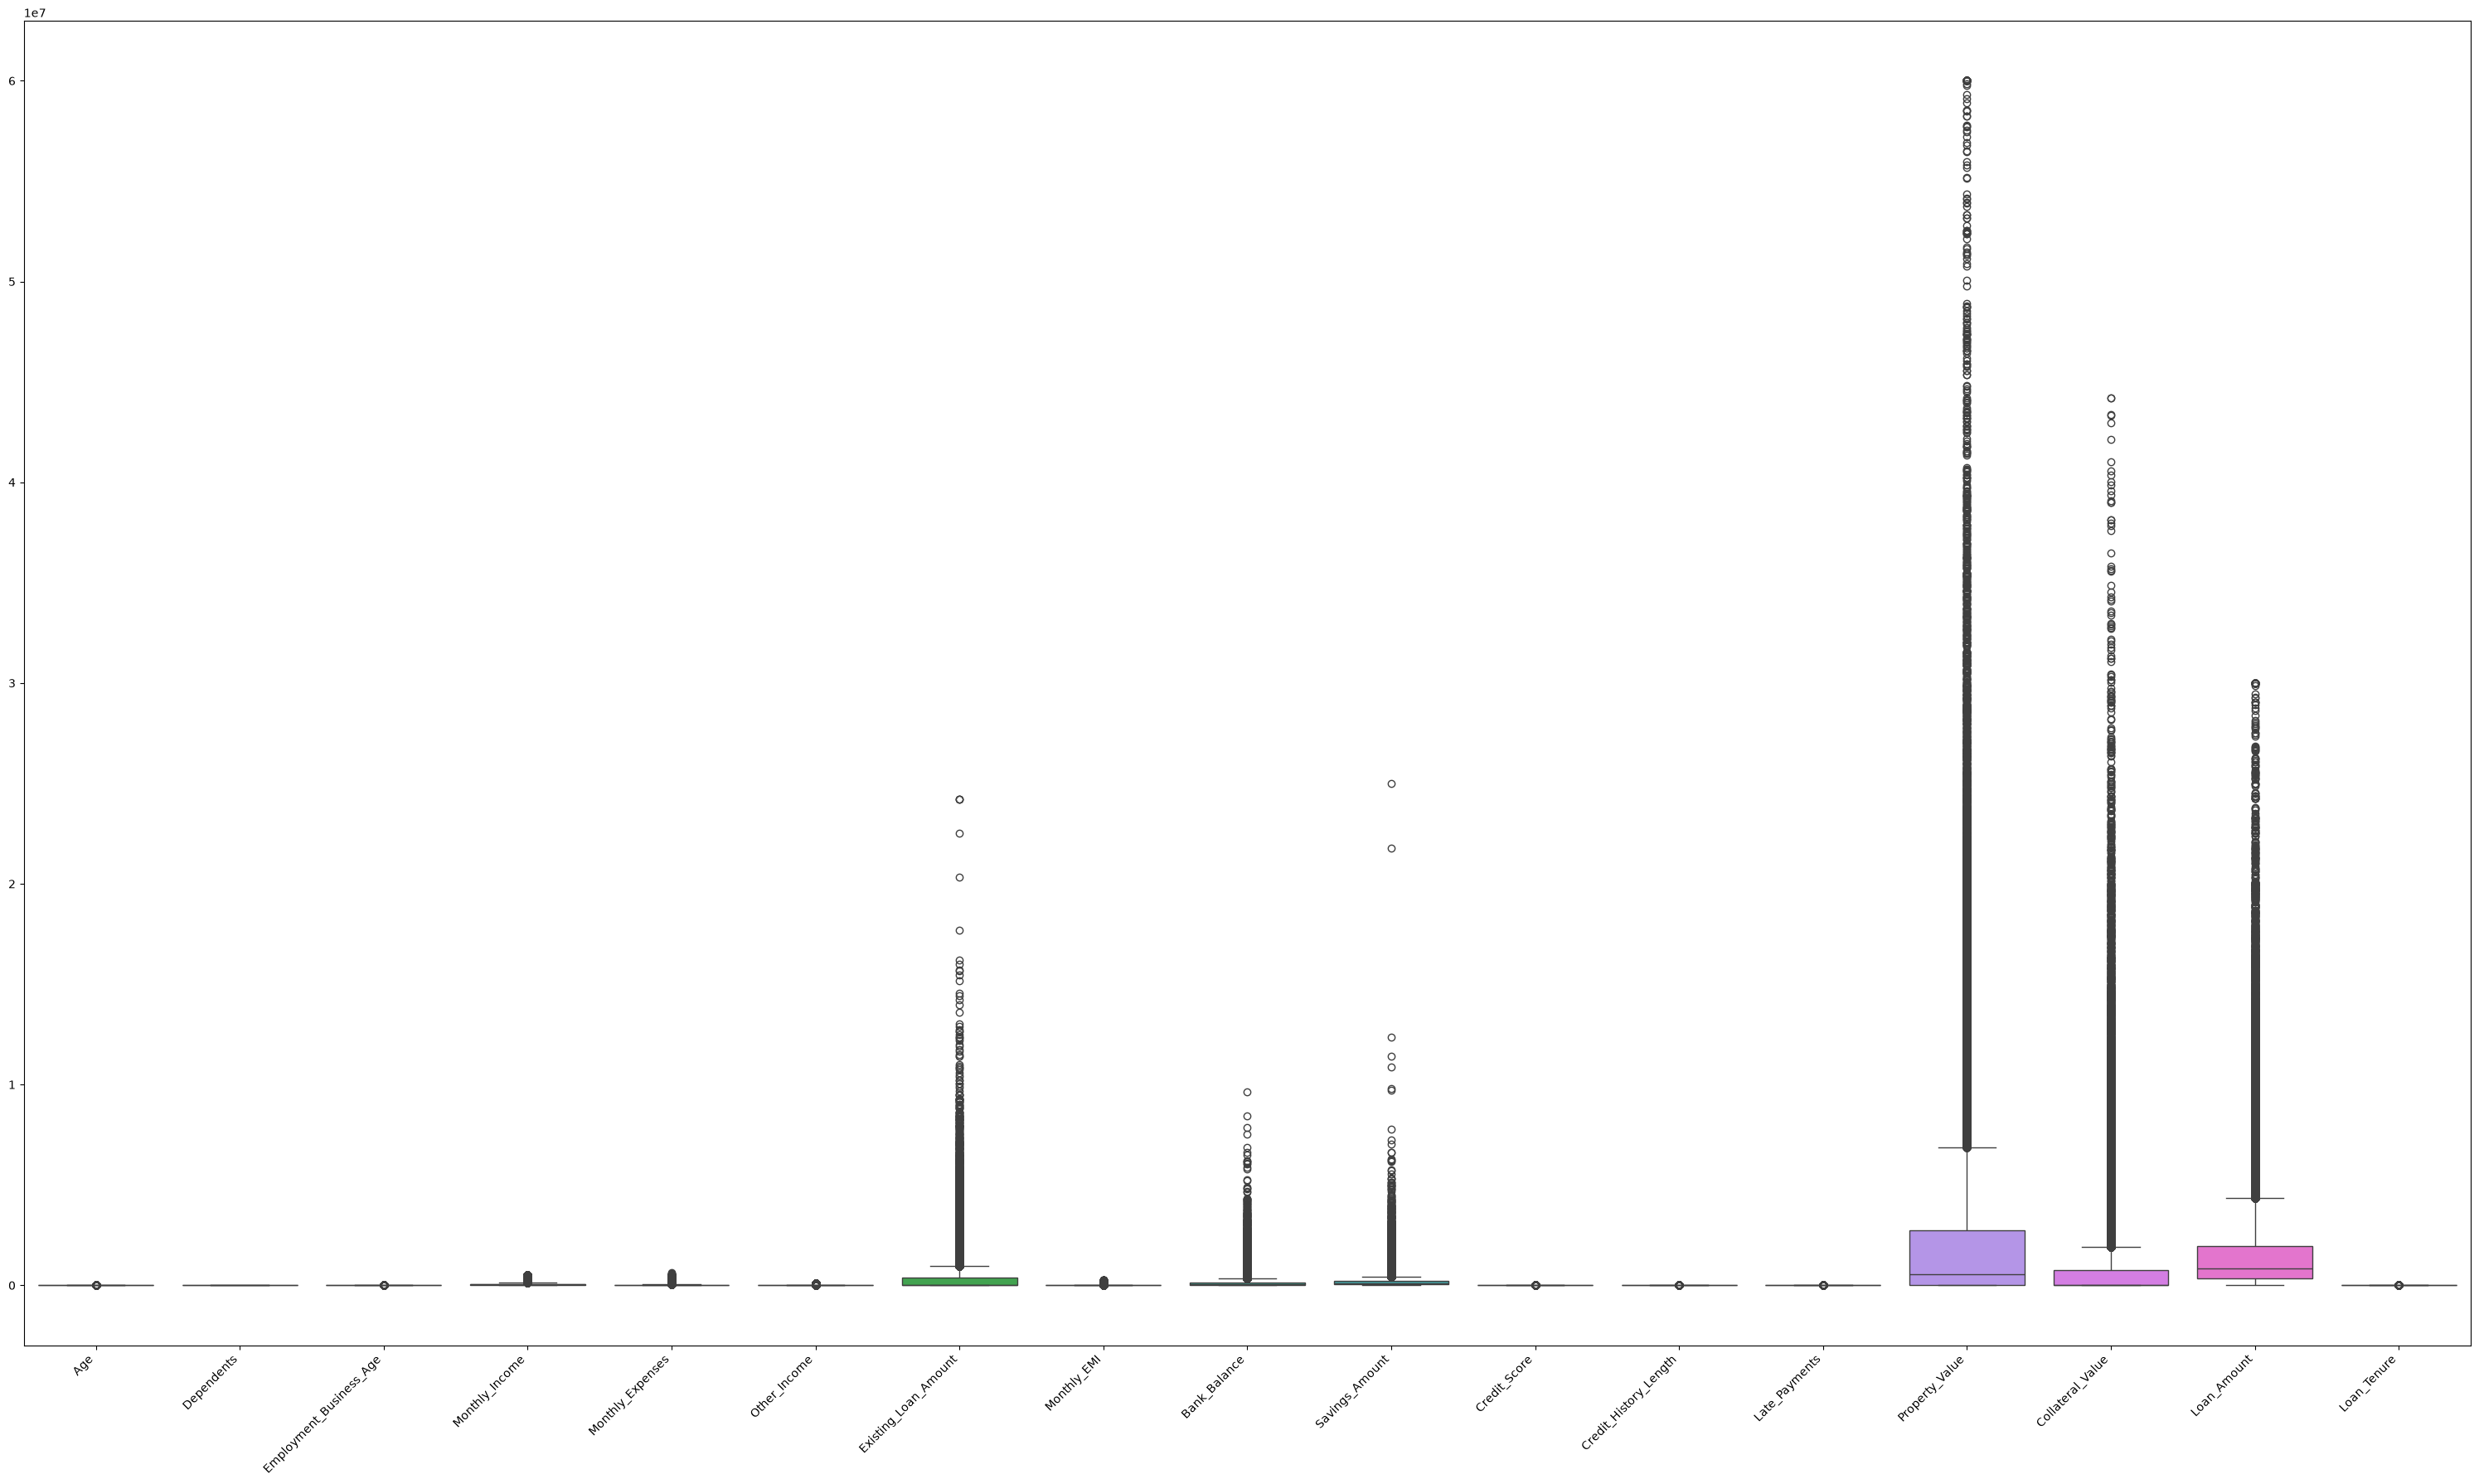

In [20]:
plt.figure(figsize=(30,18))

sns.boxplot(data=data[select_numeric_data])

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [21]:
# Select all numeric columns
select_numeric_data = data.select_dtypes(include="number").columns

# Q1 and Q3
Q1 = data[select_numeric_data].quantile(0.25)
Q3 = data[select_numeric_data].quantile(0.75)

# IQR
IQR = Q3 - Q1

# Lower and Upper limits
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Remove all rows containing outliers
outlier_remove = data[
    ((data[select_numeric_data] >= lower) &
     (data[select_numeric_data] <= upper)).all(axis=1)
]

# Check shape
print("Before:", data.shape)
print("After:", outlier_remove.shape)

Before: (100000, 30)
After: (47325, 30)


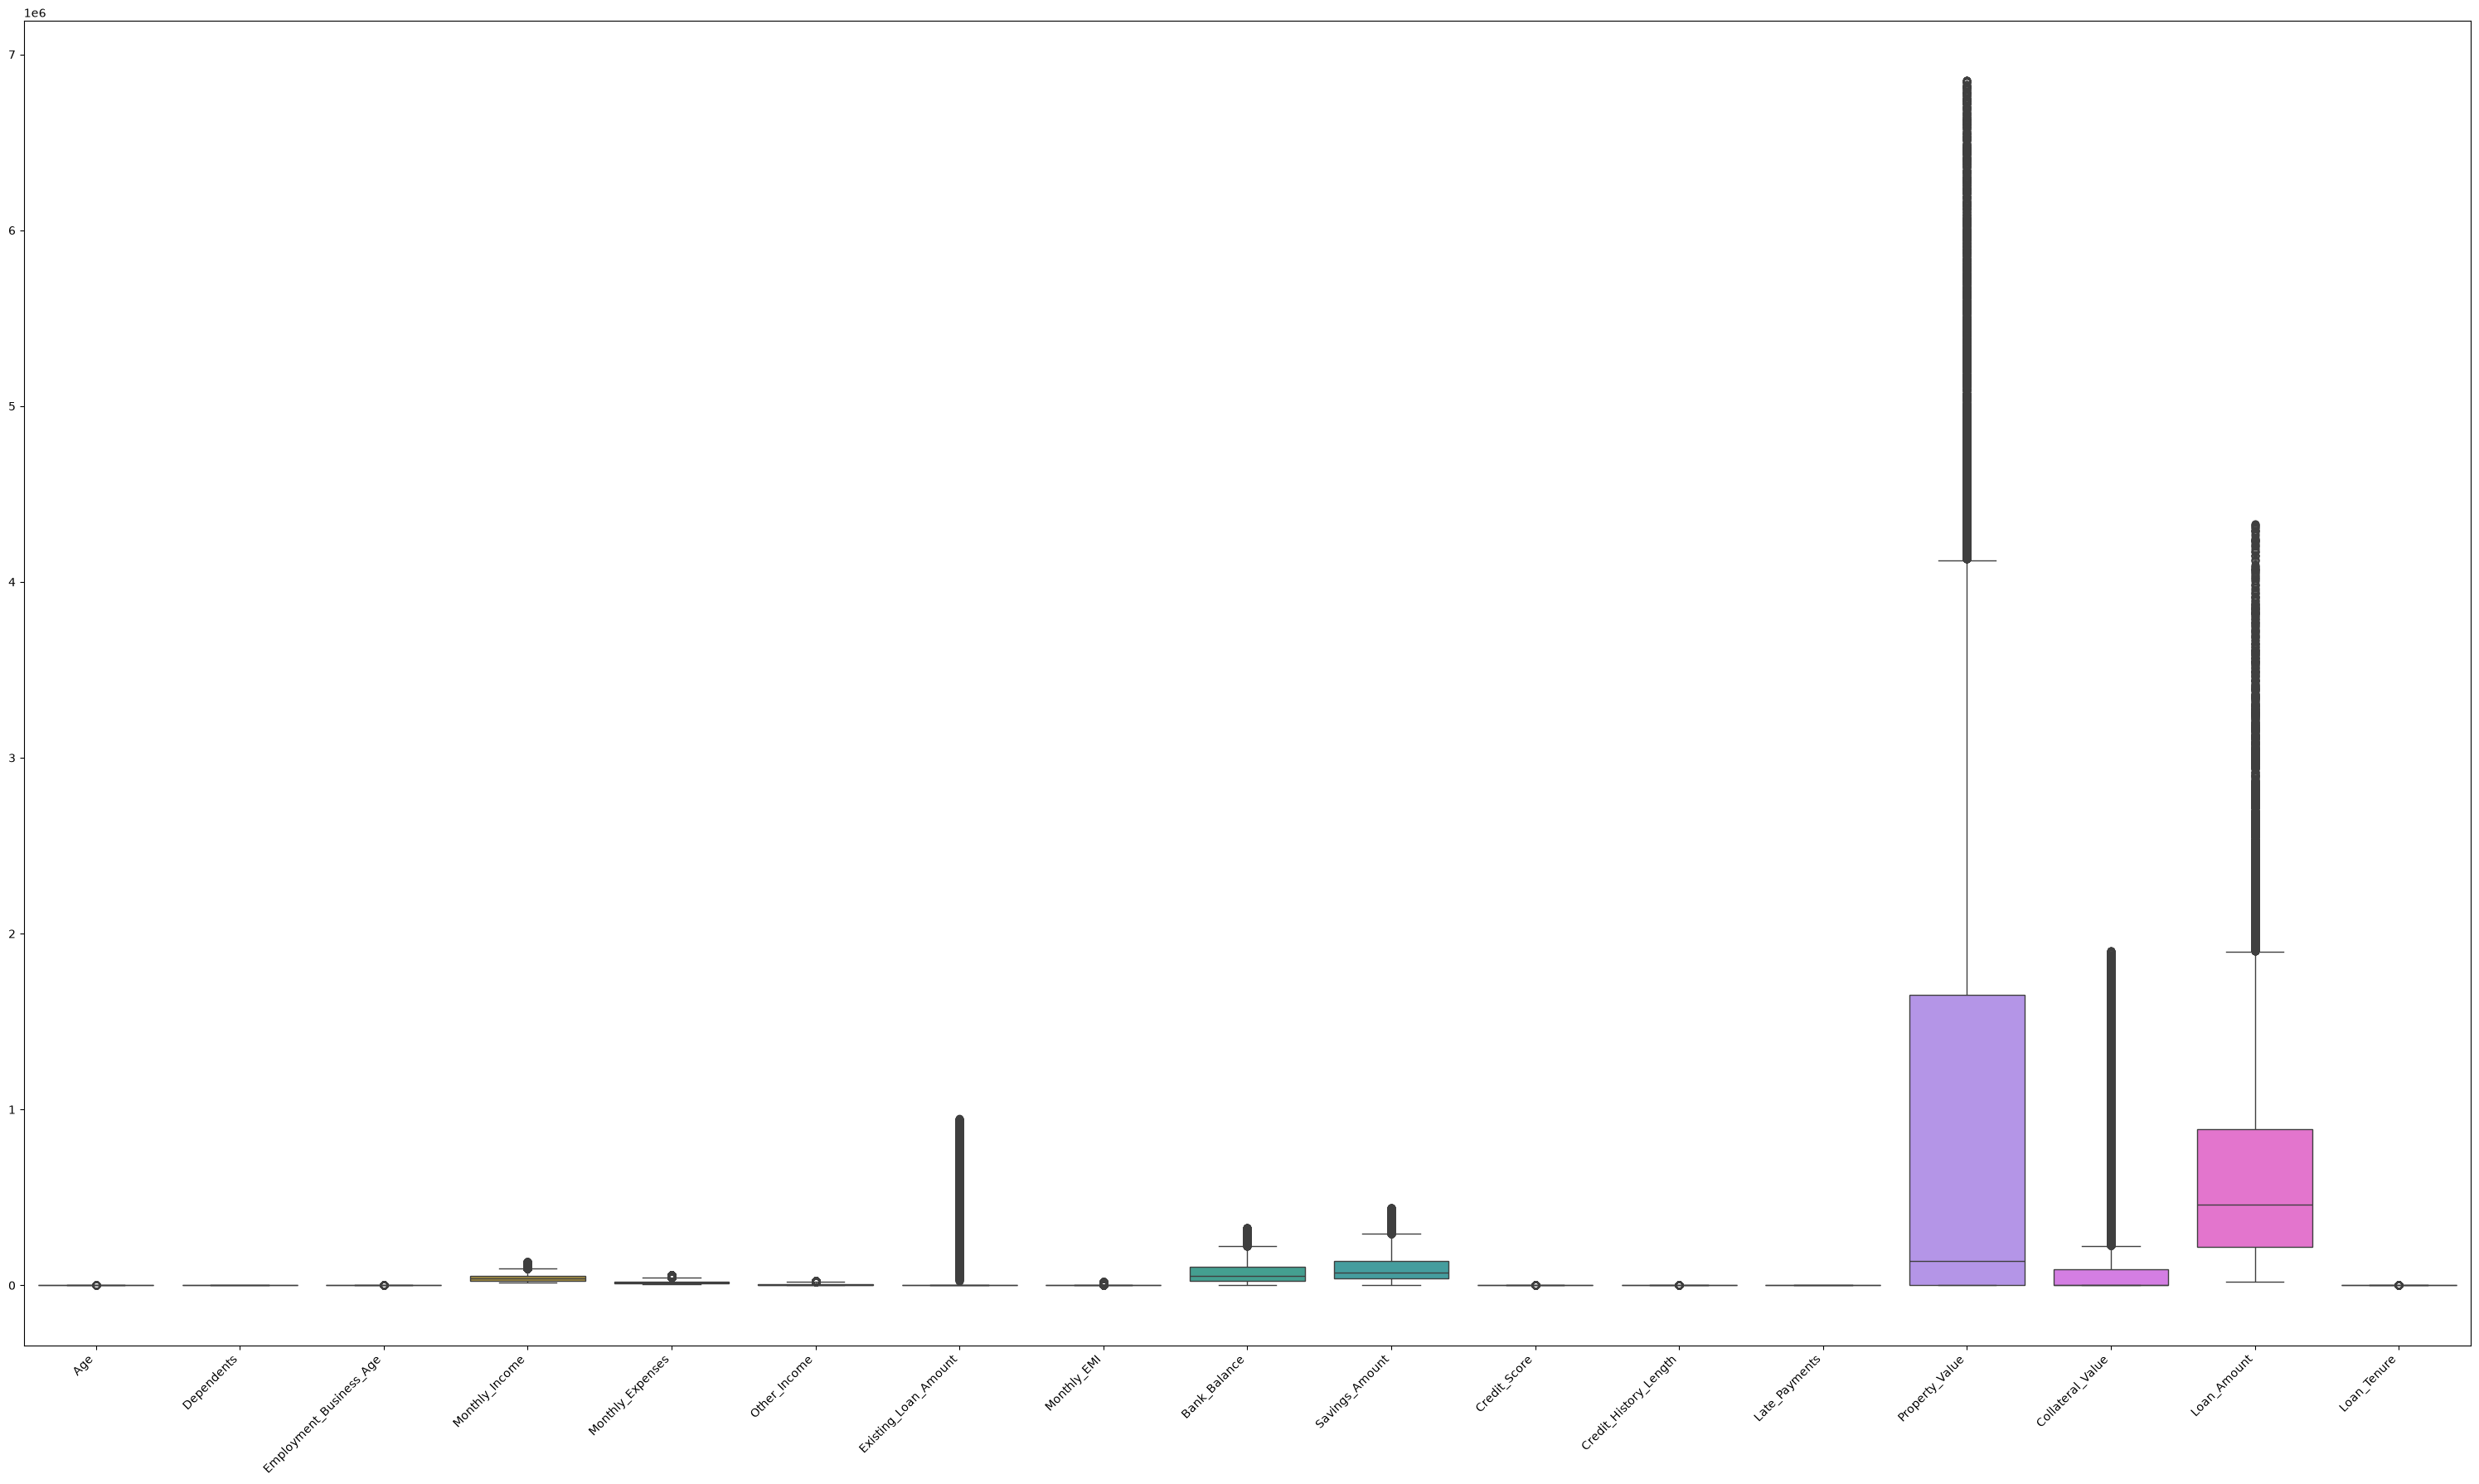

In [22]:
plt.figure(figsize=(30,18))

sns.boxplot(data=outlier_remove[select_numeric_data])

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [23]:
print("Before:", data.shape)
print("After:", outlier_remove.shape)

Before: (100000, 30)
After: (47325, 30)


In [24]:
data.head()

,Age,Gender,Marital_Status,Education,City_Type,Dependents,Applicant_Type,Employment_Type,Employment_Business_Age,Monthly_Income,...,House_Ownership,Property_Value,Vehicle_Ownership,Collateral_Value,Loan_Type,Loan_Amount,Loan_Tenure,Loan_Purpose,Previous_Loan,Loan_Approved
0,40,Male,Married,High School,Semi-Urban,1.0,Self-Employed,Self-Employed,13.0,40000.0,...,Owned,570000.0,Yes,0.000000,Home,590000,240,Home Renovation,Yes,Yes
1,27,Female,Married,Post Graduate,Rural,3.0,Business,Business,3.0,88000.0,...,Family,640000.0,Yes,450000.000000,Business,3185000,84,Working Capital,No,No
2,44,Female,Married,High School,Semi-Urban,3.0,Business,Business,17.0,145500.0,...,Owned,16640000.0,Yes,892363.574834,Personal,740000,12,Medical,Yes,Yes
3,46,Female,Married,High School,Rural,2.0,Business,Business,9.0,117500.0,...,Owned,6210000.0,No,0.000000,Home,7655000,240,Home Purchase,Yes,No
4,21,Female,Single,Graduate,Urban,0.0,Business,Business,0.0,20000.0,...,Family,1340000.0,No,0.000000,Business,925000,60,Business Expansion,Yes,No


In [25]:
#e_x=data.iloc[:,[1,2,3,4,6,7,10,12,14,17,18,19]]
le = LabelEncoder()

for col in select_object_data:
    data[col] = le.fit_transform(data[col])

In [26]:
data.head()

,Age,Gender,Marital_Status,Education,City_Type,Dependents,Applicant_Type,Employment_Type,Employment_Business_Age,Monthly_Income,...,House_Ownership,Property_Value,Vehicle_Ownership,Collateral_Value,Loan_Type,Loan_Amount,Loan_Tenure,Loan_Purpose,Previous_Loan,Loan_Approved
0,40,1,0,1,1,1.0,2,4,13.0,40000.0,...,1,570000.0,1,0.000000,2,590000,240,10,1,1
1,27,0,0,2,0,3.0,0,0,3.0,88000.0,...,0,640000.0,1,450000.000000,0,3185000,84,17,0,0
2,44,0,0,1,1,3.0,0,0,17.0,145500.0,...,1,16640000.0,1,892363.574834,3,740000,12,13,1,1
3,46,0,0,1,0,2.0,0,0,9.0,117500.0,...,1,6210000.0,0,0.000000,2,7655000,240,9,1,0
4,21,0,1,0,2,0.0,0,0,0.0,20000.0,...,0,1340000.0,0,0.000000,0,925000,60,1,1,0


In [27]:
numeric_columns = [
    "Age",
    "Dependents",
    "Employment_Business_Age",
    "Monthly_Income",
    "Property_Value",
    "Collateral_Value",
    "Loan_Amount",
    "Loan_Tenure"
]

for col in numeric_columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

In [28]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Age                      100000 non-null  int64  
 1   Gender                   100000 non-null  int32  
 2   Marital_Status           100000 non-null  int32  
 3   Education                100000 non-null  int32  
 4   City_Type                100000 non-null  int32  
 5   Dependents               100000 non-null  float64
 6   Applicant_Type           100000 non-null  int32  
 7   Employment_Type          100000 non-null  int32  
 8   Employment_Business_Age  100000 non-null  float64
 9   Monthly_Income           100000 non-null  float64
 10  Monthly_Expenses         100000 non-null  float64
 11  Other_Income             100000 non-null  float64
 12  Existing_Loan            100000 non-null  int32  
 13  Existing_Loan_Amount     100000 non-null  int64  
 14  Monthly_EMI     

In [29]:
X = data.iloc[:,:-1]
y = data["Loan_Approved"]
X,y

(       Age  Gender  Marital_Status  Education  City_Type  Dependents  \
 0       40       1               0          1          1         1.0   
 1       27       0               0          2          0         3.0   
 2       44       0               0          1          1         3.0   
 3       46       0               0          1          0         2.0   
 4       21       0               1          0          2         0.0   
 ...    ...     ...             ...        ...        ...         ...   
 99995   46       0               0          1          1         2.0   
 99996   44       0               0          0          0         2.0   
 99997   51       1               0          1          2         2.0   
 99998   36       1               0          0          1         3.0   
 99999   43       1               0          0          2         1.0   
 
        Applicant_Type  Employment_Type  Employment_Business_Age  \
 0                   2                4               

In [30]:
data.head()

,Age,Gender,Marital_Status,Education,City_Type,Dependents,Applicant_Type,Employment_Type,Employment_Business_Age,Monthly_Income,...,House_Ownership,Property_Value,Vehicle_Ownership,Collateral_Value,Loan_Type,Loan_Amount,Loan_Tenure,Loan_Purpose,Previous_Loan,Loan_Approved
0,40,1,0,1,1,1.0,2,4,13.0,40000.0,...,1,570000.0,1,0.000000,2,590000,240,10,1,1
1,27,0,0,2,0,3.0,0,0,3.0,88000.0,...,0,640000.0,1,450000.000000,0,3185000,84,17,0,0
2,44,0,0,1,1,3.0,0,0,17.0,145500.0,...,1,16640000.0,1,892363.574834,3,740000,12,13,1,1
3,46,0,0,1,0,2.0,0,0,9.0,117500.0,...,1,6210000.0,0,0.000000,2,7655000,240,9,1,0
4,21,0,1,0,2,0.0,0,0,0.0,20000.0,...,0,1340000.0,0,0.000000,0,925000,60,1,1,0


In [31]:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42
    )
    data

,Age,Gender,Marital_Status,Education,City_Type,Dependents,Applicant_Type,Employment_Type,Employment_Business_Age,Monthly_Income,...,House_Ownership,Property_Value,Vehicle_Ownership,Collateral_Value,Loan_Type,Loan_Amount,Loan_Tenure,Loan_Purpose,Previous_Loan,Loan_Approved
0,40,1,0,1,1,1.0,2,4,13.0,40000.0,...,1,570000.0,1,0.000000e+00,2,590000,240,10,1,1
1,27,0,0,2,0,3.0,0,0,3.0,88000.0,...,0,640000.0,1,4.500000e+05,0,3185000,84,17,0,0
2,44,0,0,1,1,3.0,0,0,17.0,145500.0,...,1,16640000.0,1,8.923636e+05,3,740000,12,13,1,1
3,46,0,0,1,0,2.0,0,0,9.0,117500.0,...,1,6210000.0,0,0.000000e+00,2,7655000,240,9,1,0
4,21,0,1,0,2,0.0,0,0,0.0,20000.0,...,0,1340000.0,0,0.000000e+00,0,925000,60,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,46,0,0,1,1,2.0,2,4,9.0,160000.0,...,1,8250000.0,1,5.775000e+06,0,6845000,36,1,1,0
99996,44,0,0,0,0,2.0,0,0,20.0,20000.0,...,1,430000.0,0,2.650000e+05,0,230000,48,1,1,0
99997,51,1,0,1,2,2.0,0,0,24.0,120500.0,...,1,3230000.0,1,6.035000e+06,2,4390000,180,8,1,1
99998,36,1,0,0,1,3.0,0,0,6.0,210500.0,...,0,3500000.0,0,2.450000e+06,0,8850000,84,1,1,0


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
data.head()

,Age,Gender,Marital_Status,Education,City_Type,Dependents,Applicant_Type,Employment_Type,Employment_Business_Age,Monthly_Income,...,House_Ownership,Property_Value,Vehicle_Ownership,Collateral_Value,Loan_Type,Loan_Amount,Loan_Tenure,Loan_Purpose,Previous_Loan,Loan_Approved
0,40,1,0,1,1,1.0,2,4,13.0,40000.0,...,1,570000.0,1,0.000000,2,590000,240,10,1,1
1,27,0,0,2,0,3.0,0,0,3.0,88000.0,...,0,640000.0,1,450000.000000,0,3185000,84,17,0,0
2,44,0,0,1,1,3.0,0,0,17.0,145500.0,...,1,16640000.0,1,892363.574834,3,740000,12,13,1,1
3,46,0,0,1,0,2.0,0,0,9.0,117500.0,...,1,6210000.0,0,0.000000,2,7655000,240,9,1,0
4,21,0,1,0,2,0.0,0,0,0.0,20000.0,...,0,1340000.0,0,0.000000,0,925000,60,1,1,0


In [33]:
logistic = LogisticRegression(max_iter=5000)

logistic.fit(X_train, y_train)

y_pred_logistic = logistic.predict(X_test)

print("\nLogistic Regression")
print("Accuracy :", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall   :", recall_score(y_test, y_pred_logistic))
print("F1 Score :", f1_score(y_test, y_pred_logistic))
y_pred_logistic


Logistic Regression
Accuracy : 0.7729
Precision: 0.7597603401623502
Recall   : 0.9355069014754879
F1 Score : 0.8385238907849829


C:\Users\aryan\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([1, 1, 1, ..., 1, 1, 1])

In [34]:
svm = SVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("\nSVM")
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))
y_pred_svm


SVM
Accuracy : 0.6944
Precision: 0.6917897223862965
Recall   : 0.9290813898143742
F1 Score : 0.7930660888407367


array([1, 1, 1, ..., 1, 1, 1])

In [36]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))

Accuracy: 0.6802
Precision: 0.6714742853939968
Recall: 0.6802
F1 Score: 0.6732590930621276


In [37]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))

Accuracy: 0.7392
Precision: 0.7410239686651404
Recall: 0.7392
F1 Score: 0.740009641792726


In [38]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))

Accuracy: 0.81235
Precision: 0.8103998591179259
Recall: 0.81235
F1 Score: 0.8089262861116827


In [39]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(estimators=[("logistic", logistic),("svm", svm),("knn", knn),("dt", dt),("rf", rf)],voting="hard")
voting.fit(X_train, y_train)
y_pred = voting.predict(X_test)
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))

C:\Users\aryan\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.77995
Precision: 0.7869323201665765
Recall: 0.77995
F1 Score: 0.7659493421842964
